In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns 
import numpy as np
import os, sys, re
from ast import literal_eval

In [78]:
PATH = os.getcwd().split('/')[:-1]
PATH = "/".join(PATH)

PLOTS = os.getcwd()
RESULTS = f"{PATH}/results"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12
})


In [87]:
def process_file(filename):
    # Skip metadata header (first 5 lines)
    # df = pd.read_csv(filename, header=4, skipfooter=2, engine='python')
    df = pd.read_csv(filename)
    
    # Parse 'results' column (JSON-like string to dict)
    df['counts'] = df['results'].apply(lambda x: literal_eval(x) if isinstance(x, str) else {})
    
    # Extract Target/Secret String from Metadata
    def get_target(meta):
        if pd.isna(meta): return None
        # Try BV format then Grover format
        match = re.search(r'(?:Secret number|Target string):\s*([01]+)', meta)
        return match.group(1) if match else None

    df['target_string'] = df['metadata'].apply(get_target)
    
    # Calculate Fidelity
    def calc_prob(row):
        target = row['target_string']
        counts = row['counts']
        shots = row['shots']
        if target and target in counts:
            return counts[target] / shots
        return 0.0

    df['fidelity'] = df.apply(calc_prob, axis=1)

    df['latency'] = (pd.to_datetime(df['end_time']) - pd.to_datetime(df['created_time'])).dt.total_seconds()

    return df


In [88]:
ibm_g_df = process_file(f"{RESULTS}/ibm_pittsburgh_2026-02-10_grover.csv")
ibm_bv_df = process_file(f"{RESULTS}/ibm_pittsburgh_2026-02-10_bv.csv")

ibm_bv_df

,Unnamed: 0,problem,num_qubits,shots,created_time,end_time,time_ms,usage_estimation,results,metadata,error_data,counts,target_string,fidelity,latency
0,0,Bernstein-Vazirani,4,1024,2026-02-10T15:16:47.986Z,2026-02-10T15:16:52.784Z,5708.176,NaN,"{'110': 981, '100': 13, '010': 25, '000': 4, '...",Secret number: 110,"{'q148': {'T1': 0.0003012158103518112, 'T2': 0...","{'110': 981, '100': 13, '010': 25, '000': 4, '...",110,0.958008,4.798
1,1,Bernstein-Vazirani,4,1024,2026-02-10T15:16:59.624Z,2026-02-10T15:17:05.660Z,6454.303,NaN,"{'101': 966, '100': 8, '001': 39, '111': 5, '0...",Secret number: 101,"{'q112': {'T1': 0.00031988513288904857, 'T2': ...","{'101': 966, '100': 8, '001': 39, '111': 5, '0...",101,0.943359,6.036
2,2,Bernstein-Vazirani,4,1024,2026-02-10T15:17:12.442Z,2026-02-10T15:17:51.976Z,39972.571,NaN,"{'001': 980, '000': 12, '101': 30, '011': 2}",Secret number: 001,"{'q148': {'T1': 0.0003012158103518112, 'T2': 0...","{'001': 980, '000': 12, '101': 30, '011': 2}",001,0.957031,39.534
3,3,Bernstein-Vazirani,4,1024,2026-02-10T15:17:58.739Z,2026-02-10T15:18:03.804Z,5560.033,NaN,"{'010': 994, '000': 7, '011': 21, '110': 2}",Secret number: 010,"{'q55': {'T1': 0.00031918378274550774, 'T2': 0...","{'010': 994, '000': 7, '011': 21, '110': 2}",010,0.970703,5.065
4,4,Bernstein-Vazirani,4,1024,2026-02-10T15:18:10.658Z,2026-02-10T15:18:15.457Z,5340.733,NaN,"{'101': 982, '001': 22, '000': 5, '100': 11, '...",Secret number: 101,"{'q112': {'T1': 0.00031988513288904857, 'T2': ...","{'101': 982, '001': 22, '000': 5, '100': 11, '...",101,0.958984,4.799
5,5,Bernstein-Vazirani,4,1024,2026-02-10T15:18:22.430Z,2026-02-10T15:19:04.504Z,42628.142,3.103704,"{'010': 992, '011': 16, '000': 14, '110': 2}",Secret number: 010,"{'q55': {'T1': 0.00031918378274550774, 'T2': 0...","{'010': 992, '011': 16, '000': 14, '110': 2}",010,0.968750,42.074
6,6,Bernstein-Vazirani,4,1024,2026-02-10T15:19:11.405Z,2026-02-10T15:20:37.980Z,87151.633,2.348954,"{'101': 984, '001': 20, '000': 4, '111': 1, '1...",Secret number: 101,"{'q112': {'T1': 0.00031988513288904857, 'T2': ...","{'101': 984, '001': 20, '000': 4, '111': 1, '1...",101,0.960938,86.575
7,7,Bernstein-Vazirani,4,1024,2026-02-10T15:20:44.857Z,2026-02-10T15:21:41.793Z,57428.432,NaN,"{'010': 987, '011': 23, '000': 11, '110': 3}",Secret number: 010,"{'q55': {'T1': 0.00031918378274550774, 'T2': 0...","{'010': 987, '011': 23, '000': 11, '110': 3}",010,0.963867,56.936
8,8,Bernstein-Vazirani,4,1024,2026-02-10T15:21:48.617Z,2026-02-10T15:22:48.979Z,60742.977,NaN,"{'001': 989, '101': 22, '000': 8, '011': 4, '1...",Secret number: 001,"{'q148': {'T1': 0.0003012158103518112, 'T2': 0...","{'001': 989, '101': 22, '000': 8, '011': 4, '1...",001,0.965820,60.362
9,9,Bernstein-Vazirani,4,1024,2026-02-10T15:22:55.885Z,2026-02-10T15:23:00.942Z,5792.113,NaN,"{'100': 996, '101': 18, '000': 7, '110': 3}",Secret number: 100,"{'q55': {'T1': 0.00031918378274550774, 'T2': 0...","{'100': 996, '101': 18, '000': 7, '110': 3}",100,0.972656,5.057


In [107]:
ibm_g_df.iloc[0]['latency']

np.float64(4.928)

In [97]:
def plot_hist(df, machine=None, problem=None, qubits=4, idx=0):
    r = df[df['num_qubits'] == qubits].iloc[idx]
    result = literal_eval(r['results'])

    fig, ax = plt.subplots()
    bar_container = ax.bar(result.keys(), result.values(), align='center')
    ax.set(
        ylabel='Shot Count', 
        title=f'{machine} - {problem} results\n{r['metadata']}', 
        xticks=list(result.keys()),
        xticklabels=result.keys(),
    )
    ax.bar_label(bar_container, fmt='{:,.0f}')
    ax.tick_params(axis='x', rotation=45)

    plt.show()

def plot_paper_quality(df, machine="IBM Boston", title=""):
    # Data Prep
    y = df['latency'].values
    qubit_counts = df['num_qubits'].values
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 1. Plot the data
    # zorder=10 ensures the line sits ON TOP of the background shading
    ax.plot(range(len(y)), y, color='#2c3e50', linewidth=1.5, label='Run Time', zorder=10)

    # 2. Setup Shaded Regions & Top Labels
    # Find indices where qubit count changes
    changes = [0] + [i for i in range(1, len(qubit_counts)) if qubit_counts[i] != qubit_counts[i-1]] + [len(qubit_counts)]
    colors = ["#dddddd", '#ffffff'] # Alternating subtle background colors
    
    # Get the transform for placing text relative to the top of the axis
    trans = ax.get_xaxis_transform()

    for k in range(len(changes) - 1):
        start = changes[k]
        end = changes[k+1]
        
        # A. Shade the background
        # We shade from (start-0.5) to (end-0.5) to perfectly frame the data points
        ax.axvspan(start - 0.5, end - 0.5, color=colors[k % 2], alpha=1, zorder=0)
        
        # B. Add Label at the top
        mid_point = (start + end - 1) / 2
        ax.text(mid_point, 0.95, f"{qubit_counts[start]} Qubits", 
                transform=trans,             # Use axis coordinates (0-1) for Y
                ha='center', va='top',       # Anchor top of text to the 0.95 line
                fontsize=10, fontweight='bold', color='#555555')

    # 3. Clean Axes & Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # 4. Labeling
    ax.set_ylabel("Latency (sec)", fontsize=11)
    ax.set_xlabel("Experiment Run Index", fontsize=11)
    
    # Snap the margins to the data limits (removes side gaps)
    ax.margins(x=0)
    
    # 5. Handle Annotations
    # Normalize string check (e.g., allow "IBM Boston" or "IBM_Boston")
    if "Boston" in machine: 
        # Note: Ensure these coordinates match your specific data spikes
        ax.annotate('Queue Delay', xy=(11, 35000), xytext=(12, 30000), 
                    arrowprops=dict(arrowstyle='->', lw=1), fontsize=9)

    ax.set_title(title)

    plt.tight_layout()
    plt.show()

def plot_success_boxplot(df, algorithm_name="Bernstein-Vazirani"):
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Create Box Plot
    # 'num_qubits' on X, 'fidelity' on Y
    sns.boxplot(x='num_qubits', y='fidelity', data=df, color='#e0e0e0', width=0.5, linewidth=1.5, ax=ax)
    
    # Overlay individual data points (swarmplot) so reviewers see n=20 isn't fake
    sns.swarmplot(x='num_qubits', y='fidelity', data=df, color='#2c3e50', alpha=0.7, size=5, ax=ax)

    # Styling
    ax.set_xlabel("Qubit Count (Problem Size)")
    ax.set_ylabel("Fidelity")
    ax.set_ylim(-0.05, 1.05) # Keep range 0-1
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Add a caption-like title at bottom if needed, or simple title
    ax.set_title(f"{algorithm_name} - Fidelity vs Scale", pad=20)
    
    plt.tight_layout()
    plt.show()

def plot_clean_histogram(counts, correct_bitstring, title="8 Qubits"):
    # Sort counts and take top 10 to avoid overcrowding
    sorted_counts = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True)[:10])
    
    keys = list(sorted_counts.keys())
    values = list(sorted_counts.values())
    
    # Color logic: Highlight the correct answer
    colors = ['#2c3e50' if k == correct_bitstring else '#b0b0b0' for k in keys]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(keys, values, color=colors)
    
    ax.set_ylabel("Shot Counts")
    ax.set_title(title)
    
    # Rotate labels for readability
    plt.xticks(rotation=45, ha='right')
    
    # Highlight the correct one
    if correct_bitstring in keys:
        idx = keys.index(correct_bitstring)
        ax.annotate("Correct", xy=(idx, values[idx]), xytext=(idx, values[idx]+50), ha='center', arrowprops=dict(arrowstyle='->'))

    plt.tight_layout()
    plt.show()

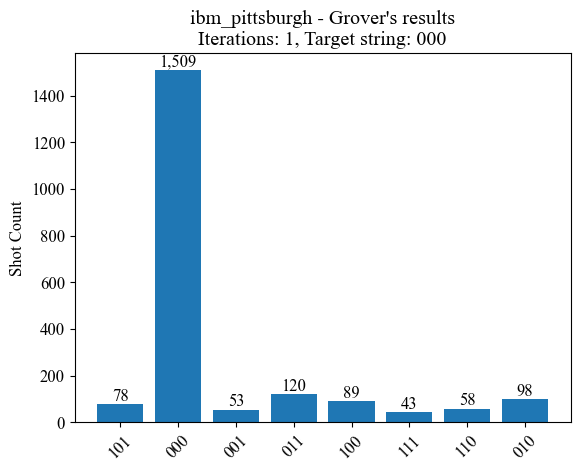

In [104]:
plot_hist(ibm_g_df, "ibm_pittsburgh", "Grover's", 3, 0)

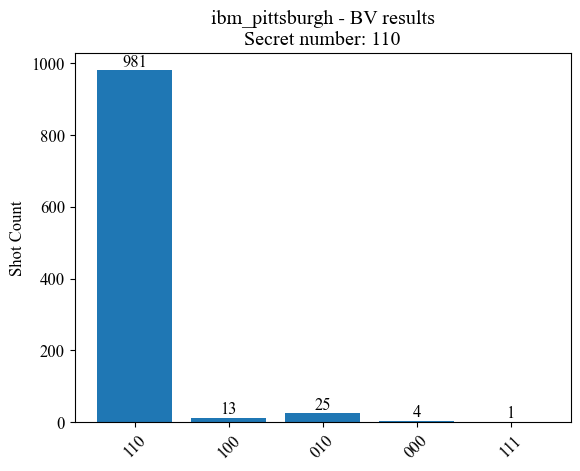

In [105]:
plot_hist(ibm_bv_df, "ibm_pittsburgh", "BV", 4, 0)

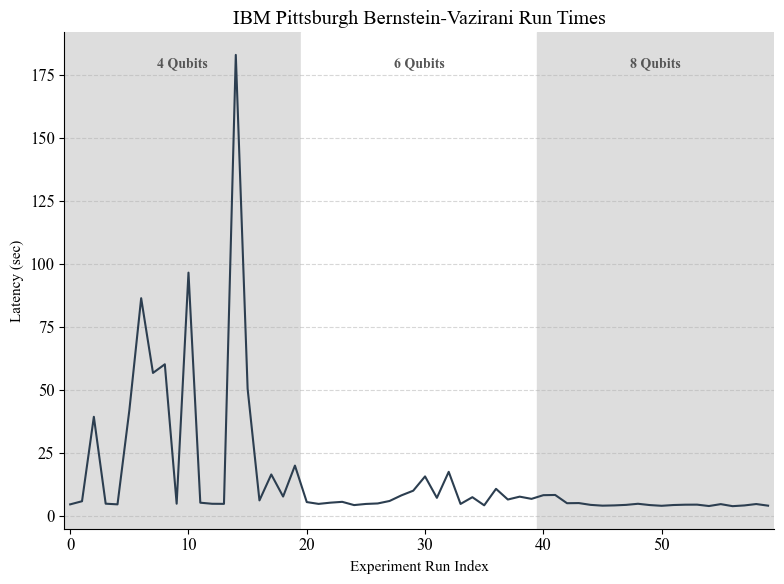

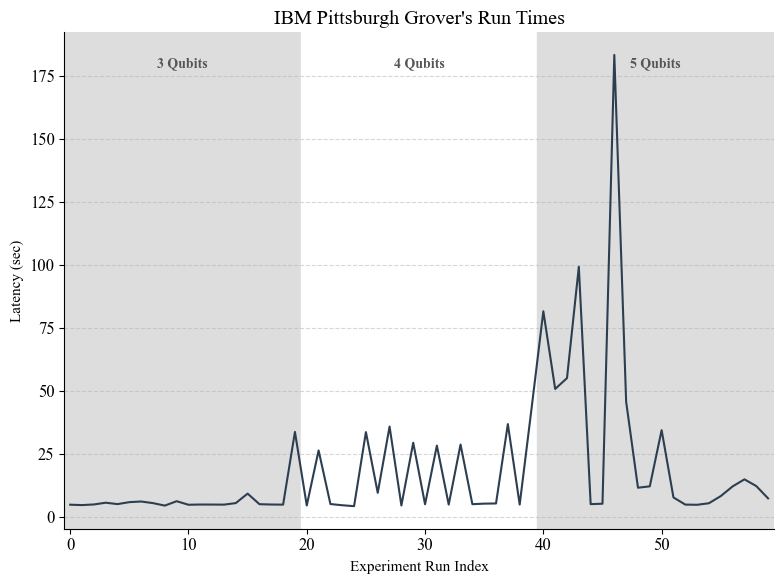

In [98]:
plot_paper_quality(ibm_bv_df, "IBM Pittsburgh", "IBM Pittsburgh Bernstein-Vazirani Run Times")
plot_paper_quality(ibm_g_df, "IBM Pittsburgh", "IBM Pittsburgh Grover's Run Times")

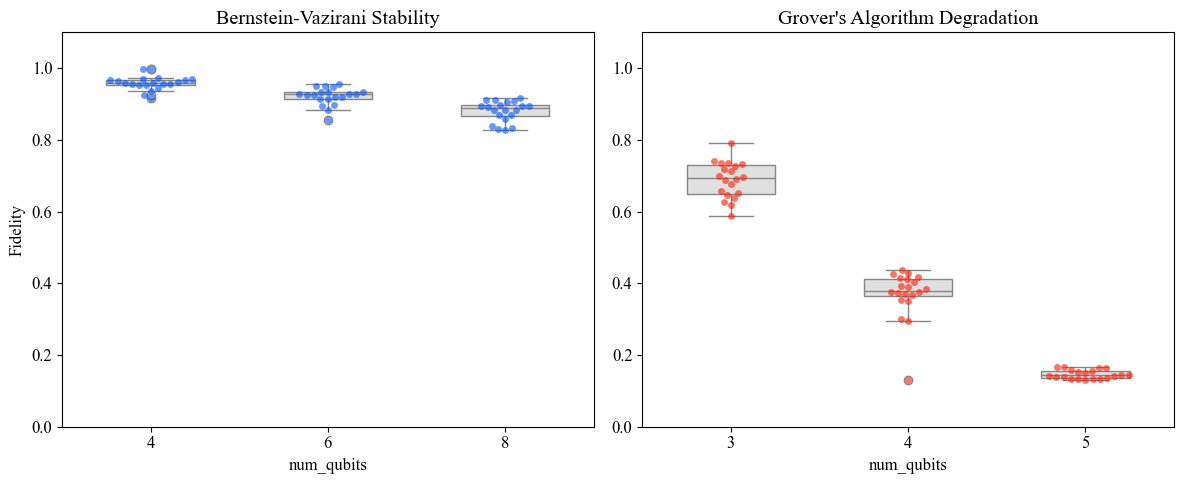

In [99]:
# --- Fidelity vs Scale (Box Plots) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# BV Plot
# bv_data = df[df['problem'] == 'Bernstein-Vazirani']
sns.boxplot(x='num_qubits', y='fidelity', data=ibm_bv_df, ax=axes[0], color='#e0e0e0', width=0.5)
sns.swarmplot(x='num_qubits', y='fidelity', data=ibm_bv_df, ax=axes[0], color="#0055ff", alpha=0.6)
axes[0].set_title("Bernstein-Vazirani Stability")
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Fidelity")

# Grover Plot
# grover_data = df[df['problem'] == "Grover's Algorithm"]
sns.boxplot(x='num_qubits', y='fidelity', data=ibm_g_df, ax=axes[1], color='#e0e0e0', width=0.5)
sns.swarmplot(x='num_qubits', y='fidelity', data=ibm_g_df, ax=axes[1], color="#ff1900", alpha=0.6)
axes[1].set_title("Grover's Algorithm Degradation")
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("") 

plt.tight_layout()
plt.show()

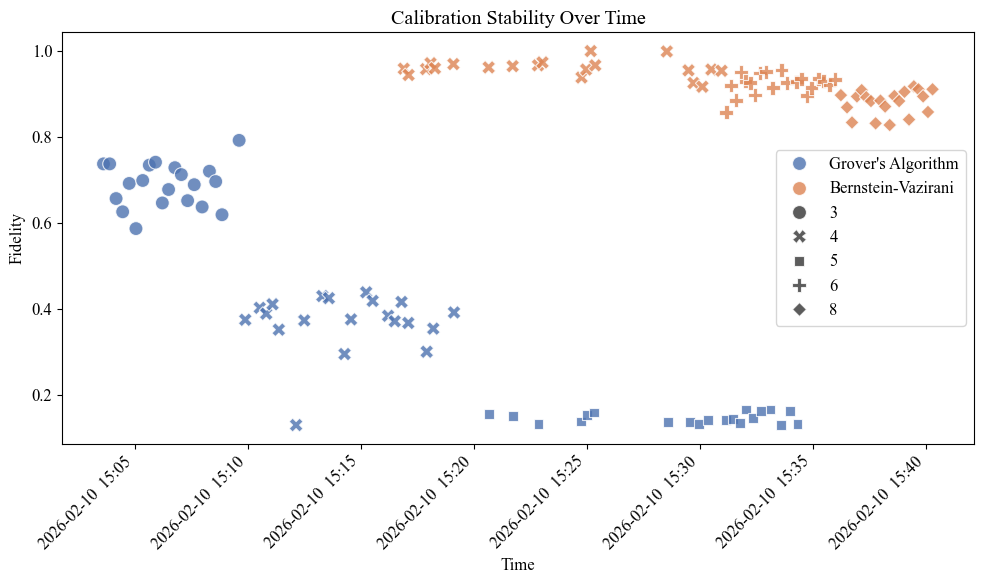

In [100]:
# --- Time vs. Fidelity ---
df = pd.concat([ibm_g_df, ibm_bv_df], ignore_index=True)

df['end_time'] = pd.to_datetime(df['end_time'])
df = df.sort_values('end_time')

df.dropna(subset=['num_qubits'], inplace=True)
df['num_qubits'] = df['num_qubits'].astype(int)

# 2. Generate the Plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='end_time', 
    y='fidelity', 
    hue='problem',       # Colors differentiate BV vs Grover
    style='num_qubits',  # Shapes differentiate 4 vs 6 vs 8 qubits
    s=100,               # Marker size
    alpha=0.8,           # Transparency
    palette='deep',
    ax=ax
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d  %H:%M'))

# FIX 2: Anchor the rotation to the 'right'
plt.xticks(rotation=45, ha='right')

# 3. Labeling
ax.set_ylabel("Fidelity")
ax.set_xlabel("Time")
ax.set_title("Calibration Stability Over Time")
plt.xticks(rotation=45)

# Get the default handles/labels
handles, labels = ax.get_legend_handles_labels()

# Create new lists excluding the headers
clean_handles = []
clean_labels = []
for h, l in zip(handles, labels):
    # Filter out the internal Seaborn titles
    if l not in ['problem', 'num_qubits']:
        clean_handles.append(h)
        clean_labels.append(l)

# Re-draw the legend with only the data items
ax.legend(clean_handles, clean_labels)#, loc='upper left')#, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [101]:
def flatten_error_data(df):
    rows = []
    for idx, row in df.iterrows():
        # Parse the string dictionary into an actual dict
        error_dict = literal_eval(row['error_data'])
        
        for qubit, metrics in error_dict.items():
            rows.append({
                'exp_num': idx % len(ibm_g_df),
                'experiment_time': row['end_time'],
                'problem': row['problem'],
                'qubit': qubit,
                'T1': metrics.get('T1'),
                'T2': metrics.get('T2'),
                'readout_error': metrics.get('readout_error')
            })
    return pd.DataFrame(rows)

def extract_number(q_str):
    match = re.search(r'\d+', q_str)
    return int(match.group()) if match else 0



In [102]:
df_flat = flatten_error_data(df)
df_flat = df_flat.sort_values('experiment_time')
df_flat['exp_num'] = df_flat.groupby('experiment_time').ngroup()

unique_qubits = df_flat['qubit'].unique()
sorted_qubits = sorted(unique_qubits, key=extract_number)

metrics_to_plot = [
    ('T1', 'T1 Relaxation Time (s)', 'viridis'),
    ('T2', 'T2 Dephasing Time (s)', 'plasma'),
    ('readout_error', 'Readout Error Rate', 'magma')
]


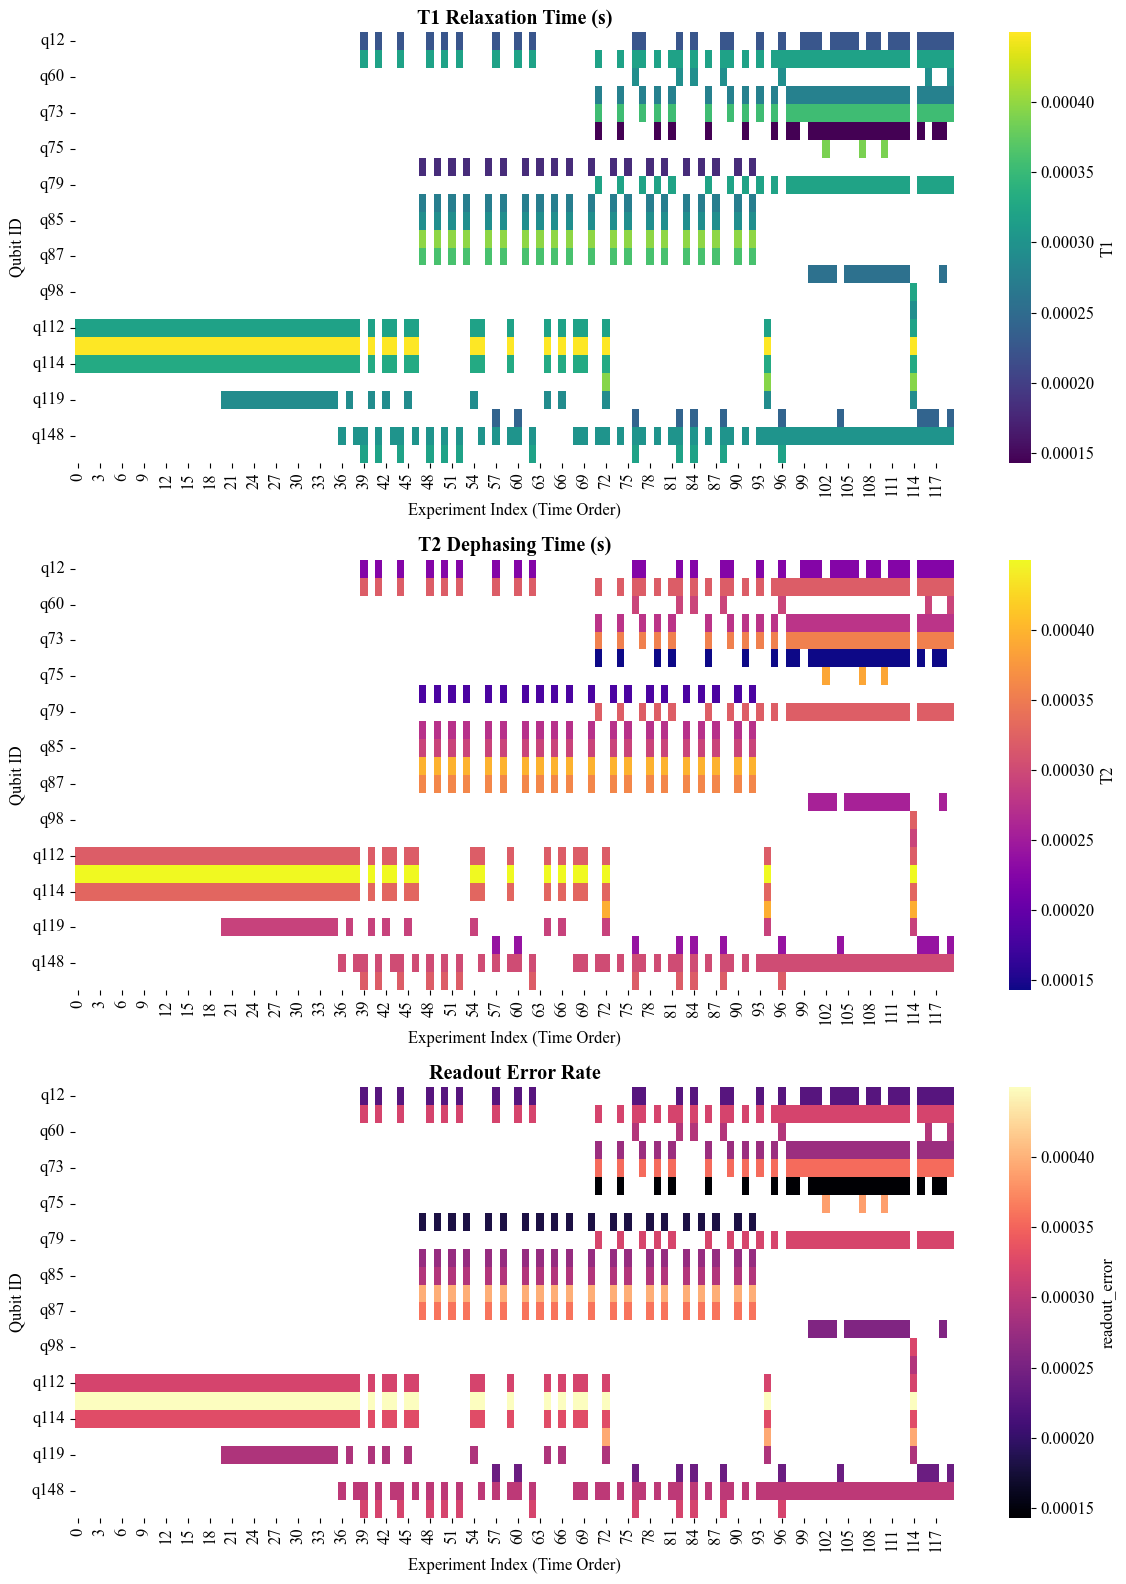

In [103]:
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(12, 16))

for i, (col, title, cmap) in enumerate(metrics_to_plot):
    # Pivot data so Qubits are rows and Experiments are columns
    pivot_df = df_flat.pivot_table(index='qubit', columns='exp_num', values='T1')
    pivot_df = pivot_df.reindex(sorted_qubits) 
    
    sns.heatmap(pivot_df, cmap=cmap, ax=axes[i], cbar_kws={'label': col})
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('Experiment Index (Time Order)')
    axes[i].set_ylabel('Qubit ID')

plt.tight_layout()
plt.show()

In [62]:
def add_created_time_to_df(df_exp, df_workload):
    """
    Merges created_time from the workload dataframe into the experiment dataframe
    based on matching the end_time (truncated to milliseconds).
    """
    # 1. Create a matching key in the workload data
    # Ensure Completed is a string and formatted correctly
    workload_map = df_workload[['Completed', 'Created']].copy()
    
    # 2. Helper to truncate experiment end_time to match workload 'Completed' (3 decimal places)
    # Example: 2026-02-10T15:03:35.708772Z -> 2026-02-10T15:03:35.708Z
    def truncate_timestamp(ts):
        if isinstance(ts, str) and '.' in ts:
            prefix, suffix = ts.split('.')
            # Keep only the first 3 digits of the fractional part
            return f"{prefix}.{suffix[:3]}Z"
        return ts

    # 3. Create the temporary matching column in the experiment DF
    df_exp = df_exp.copy()
    df_exp['match_key'] = df_exp['end_time'].apply(truncate_timestamp)

    # 4. Perform the merge
    df_merged = pd.merge(
        df_exp, 
        workload_map, 
        left_on='match_key', 
        right_on='Completed', 
        how='left'
    )

    # 5. Clean up: rename and remove helper columns
    df_merged = df_merged.rename(columns={'Created': 'created_time'})
    df_merged = df_merged.drop(columns=['match_key', 'Completed'])

    return df_merged

In [ ]:
workload_csv = '/Users/ria/Downloads/2026-02-10T05_00_00.000Z_2026-02-11T04_59_59.999Z-workloads.csv'

df_workload = pd.read_csv(workload_csv)
df_grover_updated = add_created_time_to_df(ibm_g_df, df_workload)
df_bv_updated = add_created_time_to_df(ibm_bv_df, df_workload)

In [73]:
temp_col = df_grover_updated.pop('created_time')
df_grover_updated.insert(df.columns.get_loc('end_time'), 'created_time', temp_col)

temp_col = df_bv_updated.pop('created_time')
df_bv_updated.insert(df.columns.get_loc('end_time'), 'created_time', temp_col)


In [ ]:
df_bv_updated

,problem,num_qubits,shots,created_time,end_time,time_ms,usage_estimation,results,metadata,error_data,counts,target_string,fidelity
0,Bernstein-Vazirani,4,1024,2026-02-10T15:16:47.986Z,2026-02-10T15:16:52.784Z,5708.176,NaN,"{'110': 981, '100': 13, '010': 25, '000': 4, '...",Secret number: 110,"{'q148': {'T1': 0.0003012158103518112, 'T2': 0...","{'110': 981, '100': 13, '010': 25, '000': 4, '...",110,0.958008
1,Bernstein-Vazirani,4,1024,2026-02-10T15:16:59.624Z,2026-02-10T15:17:05.660Z,6454.303,NaN,"{'101': 966, '100': 8, '001': 39, '111': 5, '0...",Secret number: 101,"{'q112': {'T1': 0.00031988513288904857, 'T2': ...","{'101': 966, '100': 8, '001': 39, '111': 5, '0...",101,0.943359
2,Bernstein-Vazirani,4,1024,2026-02-10T15:17:12.442Z,2026-02-10T15:17:51.976Z,39972.571,NaN,"{'001': 980, '000': 12, '101': 30, '011': 2}",Secret number: 001,"{'q148': {'T1': 0.0003012158103518112, 'T2': 0...","{'001': 980, '000': 12, '101': 30, '011': 2}",001,0.957031
3,Bernstein-Vazirani,4,1024,2026-02-10T15:17:58.739Z,2026-02-10T15:18:03.804Z,5560.033,NaN,"{'010': 994, '000': 7, '011': 21, '110': 2}",Secret number: 010,"{'q55': {'T1': 0.00031918378274550774, 'T2': 0...","{'010': 994, '000': 7, '011': 21, '110': 2}",010,0.970703
4,Bernstein-Vazirani,4,1024,2026-02-10T15:18:10.658Z,2026-02-10T15:18:15.457Z,5340.733,NaN,"{'101': 982, '001': 22, '000': 5, '100': 11, '...",Secret number: 101,"{'q112': {'T1': 0.00031988513288904857, 'T2': ...","{'101': 982, '001': 22, '000': 5, '100': 11, '...",101,0.958984
5,Bernstein-Vazirani,4,1024,2026-02-10T15:18:22.430Z,2026-02-10T15:19:04.504Z,42628.142,3.103704,"{'010': 992, '011': 16, '000': 14, '110': 2}",Secret number: 010,"{'q55': {'T1': 0.00031918378274550774, 'T2': 0...","{'010': 992, '011': 16, '000': 14, '110': 2}",010,0.968750
6,Bernstein-Vazirani,4,1024,2026-02-10T15:19:11.405Z,2026-02-10T15:20:37.980Z,87151.633,2.348954,"{'101': 984, '001': 20, '000': 4, '111': 1, '1...",Secret number: 101,"{'q112': {'T1': 0.00031988513288904857, 'T2': ...","{'101': 984, '001': 20, '000': 4, '111': 1, '1...",101,0.960938
7,Bernstein-Vazirani,4,1024,2026-02-10T15:20:44.857Z,2026-02-10T15:21:41.793Z,57428.432,NaN,"{'010': 987, '011': 23, '000': 11, '110': 3}",Secret number: 010,"{'q55': {'T1': 0.00031918378274550774, 'T2': 0...","{'010': 987, '011': 23, '000': 11, '110': 3}",010,0.963867
8,Bernstein-Vazirani,4,1024,2026-02-10T15:21:48.617Z,2026-02-10T15:22:48.979Z,60742.977,NaN,"{'001': 989, '101': 22, '000': 8, '011': 4, '1...",Secret number: 001,"{'q148': {'T1': 0.0003012158103518112, 'T2': 0...","{'001': 989, '101': 22, '000': 8, '011': 4, '1...",001,0.965820
9,Bernstein-Vazirani,4,1024,2026-02-10T15:22:55.885Z,2026-02-10T15:23:00.942Z,5792.113,NaN,"{'100': 996, '101': 18, '000': 7, '110': 3}",Secret number: 100,"{'q55': {'T1': 0.00031918378274550774, 'T2': 0...","{'100': 996, '101': 18, '000': 7, '110': 3}",100,0.972656


In [76]:
df_grover_updated.to_csv(f"{RESULTS}/ibm_pittsburgh_2026-02-10_grover.csv")
df_bv_updated.to_csv(f"{RESULTS}/ibm_pittsburgh_2026-02-10_bv.csv")